# Cross-currency swaps

Track principal exchanges, coupon legs and the currency used to report value.

[Chapter notes](README.md) · [All topics](../../README.md)

## Research design

A cross-currency swap exchanges cash flows in two currencies. The principal exchanges matter alongside the coupons: dropping them changes the exposure being valued.

This deliberately simple case is a five-year, fixed-for-fixed swap. At inception the holder receives EUR 100 and pays USD 110 at spot 1.10 USD/EUR. During the swap the holder pays EUR coupons and receives USD coupons; at maturity the holder returns EUR 100 and receives USD 110. Each currency's coupon is set to its own par fixed-bond rate under the declared flat curve.

For currency $c$, annual accruals and discount factors $D_c(i)$ give $k_c=[1-D_c(T)]/\sum_iD_c(i)$. The remaining-leg USD value immediately after inception is $PV_{USD\ leg}-S\,PV_{EUR\ leg}$. At par inception both legs and the initial exchanges cancel. After inception, moving the conversion spot while holding the contractual coupons and curves fixed exposes the position's FX sensitivity.

The notebook explicitly lists the time-zero and final principal exchanges, checks par leg values, and compares a finite-difference spot derivative with $-PV_{EUR\ leg}$. A separate 10-bp change to the contractual EUR coupon shows the coupon-annuity effect; it is not a calibrated market basis spread.

Assumptions are flat continuous USD 4% and EUR 2.5%, deterministic rates, annual exact-year payments, zero basis and compatible collateral. This is neither a floating-versus-floating basis-swap engine nor a collateralized multi-currency curve bootstrap. Resettable notionals, currency-specific calendars, funding, collateral and observed basis quotes remain outside this chapter. [BIS](https://www.bis.org/publications/qr-201609/covered-interest-parity-lost-understanding-cross-currency-basis) provides the institutional context for that boundary.

In [1]:
from pathlib import Path
import sys
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next(p for p in candidates if (p / 'research' / 'pricing.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql
from IPython.display import display
from research.common import RESULTS, check_hashes
from research.pricing import DATE, CAL, valuation_date, curves, fixture
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.grid':True, 'grid.alpha':.18, 'font.size':11})
# Verify the core fixture, source and saved-output vintage before reading any summary.
check_hashes()
# Every chapter uses explicit illustrative assumptions; never a hidden data download.


## Calculation and independent checks

All inputs below are illustrative. Assertions check the identities discussed in the chapter.

In [2]:
spot,eur_notional=1.10,100.0
usd_notional=spot*eur_notional
times=np.arange(1,6,dtype=float)
dusd,deur=np.exp(-.04*times),np.exp(-.025*times)
kusd,keur=(1-dusd[-1])/dusd.sum(),(1-deur[-1])/deur.sum()
usd_cash=np.full(5,usd_notional*kusd);usd_cash[-1]+=usd_notional
eur_cash=np.full(5,eur_notional*keur);eur_cash[-1]+=eur_notional
pv_usd,pv_eur=np.dot(usd_cash,dusd),np.dot(eur_cash,deur)
assert abs(pv_usd-usd_notional)<1e-10 and abs(pv_eur-eur_notional)<1e-10
assert abs(pv_usd-spot*pv_eur)<1e-10
ledger=pd.DataFrame({'year':np.r_[0,times],'USD_received':np.r_[-usd_notional,usd_cash],'EUR_received':np.r_[eur_notional,-eur_cash]})
pv=lambda s:pv_usd-s*pv_eur
assert abs((pv(spot+.0001)-pv(spot-.0001))/.0002+pv_eur)<1e-8
extra_eur_coupon_pv=-spot*eur_notional*.001*deur.sum()
display(ledger.round(6))
display(pd.DataFrame([{'USD_coupon_pct':100*kusd,'EUR_coupon_pct':100*keur,'remaining_legs_PV_USD':pv(spot),'FX_delta_USD_per_USD_EUR':-pv_eur,'PV_of_EUR_coupon_plus10bp':extra_eur_coupon_pv}]))

,year,USD_received,EUR_received
0,0.0,-110.000000,100.000000
1,1.0,4.489185,-2.531512
2,2.0,4.489185,-2.531512
3,3.0,4.489185,-2.531512
4,4.0,4.489185,-2.531512
5,5.0,114.489185,-102.531512


,USD_coupon_pct,EUR_coupon_pct,remaining_legs_PV_USD,FX_delta_USD_per_USD_EUR,PV_of_EUR_coupon_plus10bp
0,4.081077,2.531512,0.0,-100.0,-0.510578


## Economic relationship

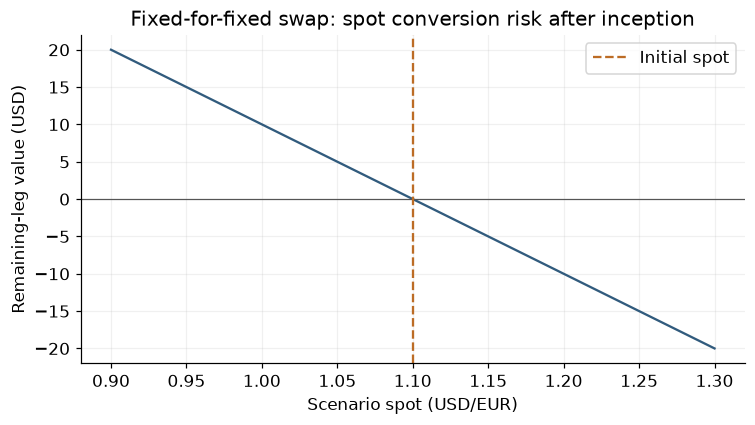

In [3]:
spots=np.linspace(.90,1.30,60)
fig,ax=plt.subplots(figsize=(7,4))
ax.plot(spots,[pv(s) for s in spots],color='#315b7d');ax.axhline(0,color='#555555',lw=.8)
ax.axvline(spot,color='#bc6c25',ls='--',label='Initial spot')
ax.set(xlabel='Scenario spot (USD/EUR)',ylabel='Remaining-leg value (USD)',title='Fixed-for-fixed swap: spot conversion risk after inception')
ax.legend();fig.tight_layout();plt.show()

## Interpretation

The two par legs and the initial principal exchange balance at inception. The remaining fixed cash flows still carry FX exposure; a zero initial value does not imply a risk-free position. No market currency basis is estimated.